#### R2P Program Unit 2: Lesson 1
## Solving your own MaxCut problem



In [1]:
# Install required python packages
# For Windows
#%pip install -U qiskit[visualization], qiskit_ibm_runtime

# For Linux and Mac
#%pip install -U "qiskit[visualization]", qiskit_ibm_runtime

In [2]:
# All imports
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np

from qiskit.quantum_info import SparsePauliOp

from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import matplotlib

from qiskit_ibm_runtime import SamplerV2 as Sampler

from typing import Sequence

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

### Throwback to previous lecture

In a previous lecture, we saw an example of solving the MaxCut problem using the QAOA algorithm.
Today we want to take a closer look at this problem, especially the first step: mapping the classical problem into something the quantum computer can work with. This mapping is the hardest part of the algorithm and it needs a certain understanding of both the problem and quantum computing. The mapping needs to be adapted specifically for each problem.


<a id="step1"></a>
<div class="alert alert-block alert-success">

**Task 1: Understanding the mapping from classical to quantum** The cell below contains code which generates a graph. What exactly does the created graph represent? Why would one choose this example for a graph for the Max Cut problem?

> The idea of this question is to try to understand the mapping part of the MaxCut, since in practice this will be the part, which needs to be done specifically for each problem.


</div> 

In [3]:
answer_task_1= " The coupling map of the physical qubits in the real quantum device. That is, it represents the physical connections between the qubits. " 

In [4]:
# QiskitRuntimeService.save_account(channel="ibm_quantum_platform",token=your_api_key,instance=your_crn,overwrite=True)
# service = QiskitRuntimeService()
# backend = service.least_busy(min_num_qubits=156)
# print(backend)

# n = 50  # Number of nodes in graph
# graph_50 = rx.PyGraph()
# graph_50.add_nodes_from(np.arange(0, n, 1))
# elist = []
# for edge in backend.coupling_map:
#     if edge[0] < n and edge[1] < n:
#         elist.append((edge[0], edge[1], 1.0))
# graph_50.add_edges_from(elist)
# draw_graph(graph_50, node_size=200, with_labels=True, width=1)

### Step 0. Find a Problem We Can Solve with Max-Cut

In the following sections, we want to use the Max-Cut problem as an example for optimization. However, this time, we want to solve a different base problem by mapping it onto the Max-Cut problem. 


Mapping a specific problem A onto a different one B allows us to use the algorithm of problem B also for problem A, this is important in quantum computing since the number of known algorithms is still small when compared to classical computing.


The problem at hand is the following:

- For complex graphs it is not easy to find a graph colouring: https://en.wikipedia.org/wiki/Graph_coloring 


- The basic idea is that you colour vertices in the graph such a way that no two connected vertices have the same colour and the goal is to use the least amount of different colours as possible. 


- Graph colouring is a graph problem which has applications in scheduling (think about planning the crew for a large airline). 


- This problem can't be directly solved with Max-Cut, but we can use the Max-Cut problem to tell us directly if a graph can be coloured by only 2 colours. 



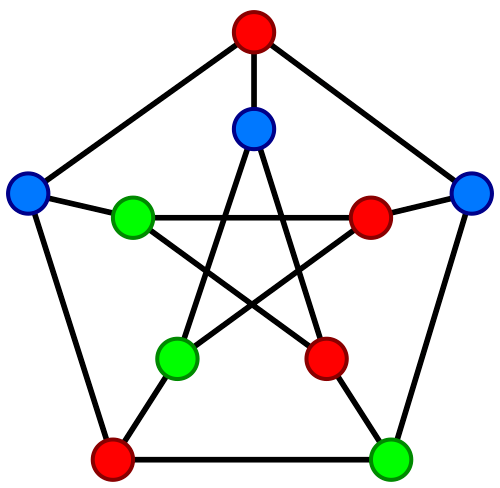


<a id="step2"></a>
<div class="alert alert-block alert-success">

**Task 2: Understanding Cutting** What will the result of the Max-Cut problem be if the graph can be coloured with only two colours? i.e. how many edges will be included in the Max-Cut.

> Hint: The result of the cut has 2 colours, how are they distributed ideally?


</div> 


In [5]:
answer_task_2= " All the edges in the graph, since if there was one that is not in the Max-Cut solution, then we would have two adjacent nodes with the same color." 

#### Step 0-2. Create a Mapping to a Graph

In this exercise, we want to teach you how one can in practice map different problems to graphs.

Here we want to map a quantum circuit, which constructs a specific quantum state to a graph. And then answer the question "is this graph 2-colourable" by solving the Max-Cut problem.

We use an ideal circuit constructing a GHZ state, because this state has many uses and we know that it maps well to our hardware. 

Below we have the ideal connections for a real quantum device in order to make a GHZ state as efficiently as possible (without using ancilla qubits). 

The GHZ state is created by first doing a Hadamard Gate on qubit 1 and then from there on we entangle the other qubits. The entangling gates used can be seen as connections on a graph. 

Create a graph which represents these connections. The lists given are representing the source and target qubit for all entangling gates used.

This code comes from the Spring Challenge 2024 where the GHZ state was used in order to encode data: https://github.com/qiskit-community/ibm-quantum-challenge-2024/blob/main/solutions/lab_bonus/bonus-lab-solutions.ipynb


You dont need to understand the linked lab. Just use the two lists of nodes below to construct your own graph.




In [6]:
# Source of the entangling gates
source_list= [1 , 1 , 2 , 2 , 3 , 3 , 4 , 5 ,  6,  7,  8,  9, 10,  8,  9, 10, 11, 12, 13, 14, 11, 15, 16, 17, 18, 19, 20, 21, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 38, 39, 40, 31, 33, 34, 35, 36, 37, 23, 25, 26]
# target of the entangling gates
target_list=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

# premade physical layout mapping the logical qubits (1-52) to physical qubits on a device.
premade_layout= [78, 69, 89, 68, 70, 90, 88, 67, 71, 91, 87, 57, 58, 92, 66, 72, 98, 97, 47, 51, 93, 86, 65, 73, 111, 107, 46, 52, 94, 48, 50, 79, 85, 64, 74, 110, 106, 45, 53, 95, 44, 54, 99, 49, 84, 63, 75, 109, 105, 77, 112, 108]



<a id="step3"></a>
<div class="alert alert-block alert-success">

**Task 3: Create Graph** Add in the below block all missing code. And then execute it and draw the graph.


</div> 

(0, 1, 1.0)
(0, 2, 1.0)
(1, 3, 1.0)
(1, 4, 1.0)
(2, 5, 1.0)
(2, 6, 1.0)
(3, 7, 1.0)
(4, 8, 1.0)
(5, 9, 1.0)
(6, 10, 1.0)
(7, 11, 1.0)
(8, 12, 1.0)
(9, 13, 1.0)
(7, 14, 1.0)
(8, 15, 1.0)
(9, 16, 1.0)
(10, 17, 1.0)
(11, 18, 1.0)
(12, 19, 1.0)
(13, 20, 1.0)
(10, 21, 1.0)
(14, 22, 1.0)
(15, 23, 1.0)
(16, 24, 1.0)
(17, 25, 1.0)
(18, 26, 1.0)
(19, 27, 1.0)
(20, 28, 1.0)
(18, 29, 1.0)
(19, 30, 1.0)
(20, 31, 1.0)
(21, 32, 1.0)
(22, 33, 1.0)
(23, 34, 1.0)
(24, 35, 1.0)
(25, 36, 1.0)
(26, 37, 1.0)
(27, 38, 1.0)
(28, 39, 1.0)
(37, 40, 1.0)
(38, 41, 1.0)
(39, 42, 1.0)
(30, 43, 1.0)
(32, 44, 1.0)
(33, 45, 1.0)
(34, 46, 1.0)
(35, 47, 1.0)
(36, 48, 1.0)
(22, 49, 1.0)
(24, 50, 1.0)
(25, 51, 1.0)


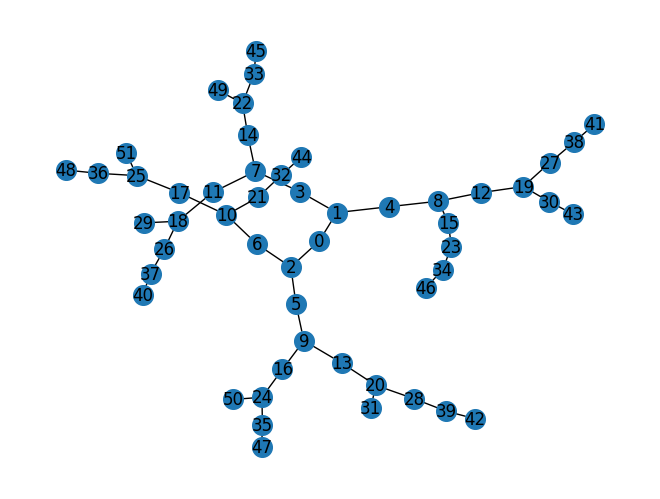

In [7]:
# How many nodes does the graph have?
n = 52  # Add Number of nodes in graph


prepared_graph = rx.PyGraph()
prepared_graph.add_nodes_from(np.arange(0, n, 1))
elist = []


#  We iterate here through the number of edges needed. Remember each edge represents 1 entangling gate.
num_steps = len(source_list) #Add code here.

for i in range(num_steps):
    # How do you get the edges?
    node1= source_list[i]-1  #add code here
    node2= target_list[i]-1  #add code here
    elist.append((node1, node2, 1.0))
    print((node1, node2, 1.0))


prepared_graph.add_edges_from(elist)
draw_graph(prepared_graph, node_size=200, with_labels=True, width=1)

### Step 1. Map Classical Inputs to a Quantum Problem


After we have mapped the classical problem to a graph, we now want to map the graph to a quantum problem.

Thanks to the helper functions, this part is not too tricky, however, we want you to understand how the observables are constructed.

#### Graph → Hamiltonian

First, you convert the graph you want to solve directly into a Hamiltonian that is suited for QAOA.

This can be done automatically with the function below.

In [8]:
from qiskit.quantum_info import SparsePauliOp
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list

In [9]:
max_cut_graph = build_max_cut_paulis(prepared_graph)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_graph)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIZIIIIIIIIII', 'IIIII

When we run the cell above, we see the cost function Hamiltonian is a SparsePauliOp object, consisting of a sum of different observables. We should understand what is happening here. 

What we can see are different observables where each one represents one edge in the graph. 

The observables have an eigenvalue of -1 if an edge is between nodes of the two different groups. 

So, by minimizing the Hamiltonian we maximize the number of edges between different groups and with this the cut. 


<a id="step4"></a>
<div class="alert alert-block alert-success">

**Task 4: Building Observables** Create (by hand) the observables for the graph in the image below (you can leave the coefficients out here).


</div> 


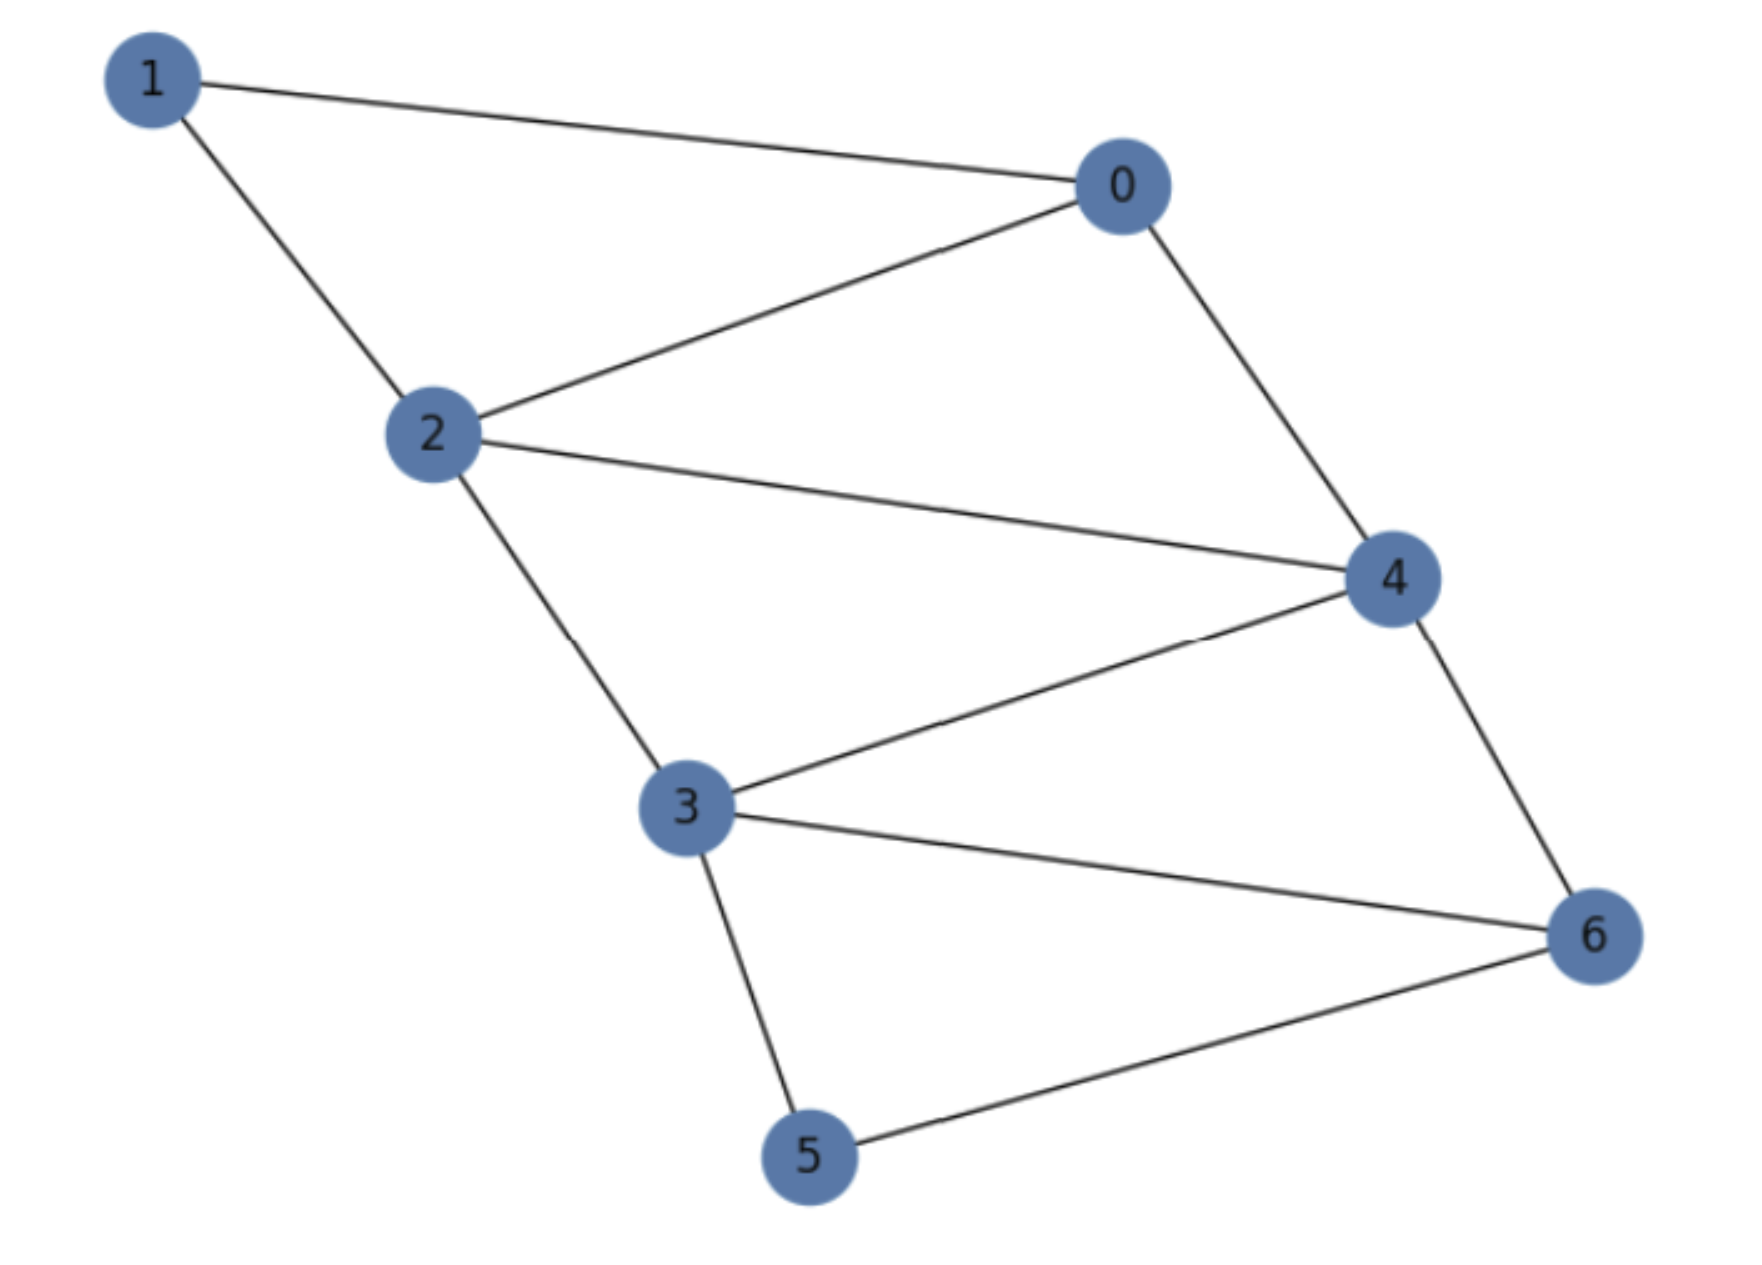

The solution is: "'ZZIIIII', 'ZIZIIII', 'IZZIIII', 'IIZZIII', 'IIZIZII', 'IIIZZII', 'IIIZIZI', 'IIIZIIZ', 'IIIIZIZ', 'IIIIIZZ'"

Note: Use little endian!

#### Hamiltonian → quantum circuit


We can now create a QAOA Ansatz directly from the above Hamiltonian using the qiskit circuit library: 

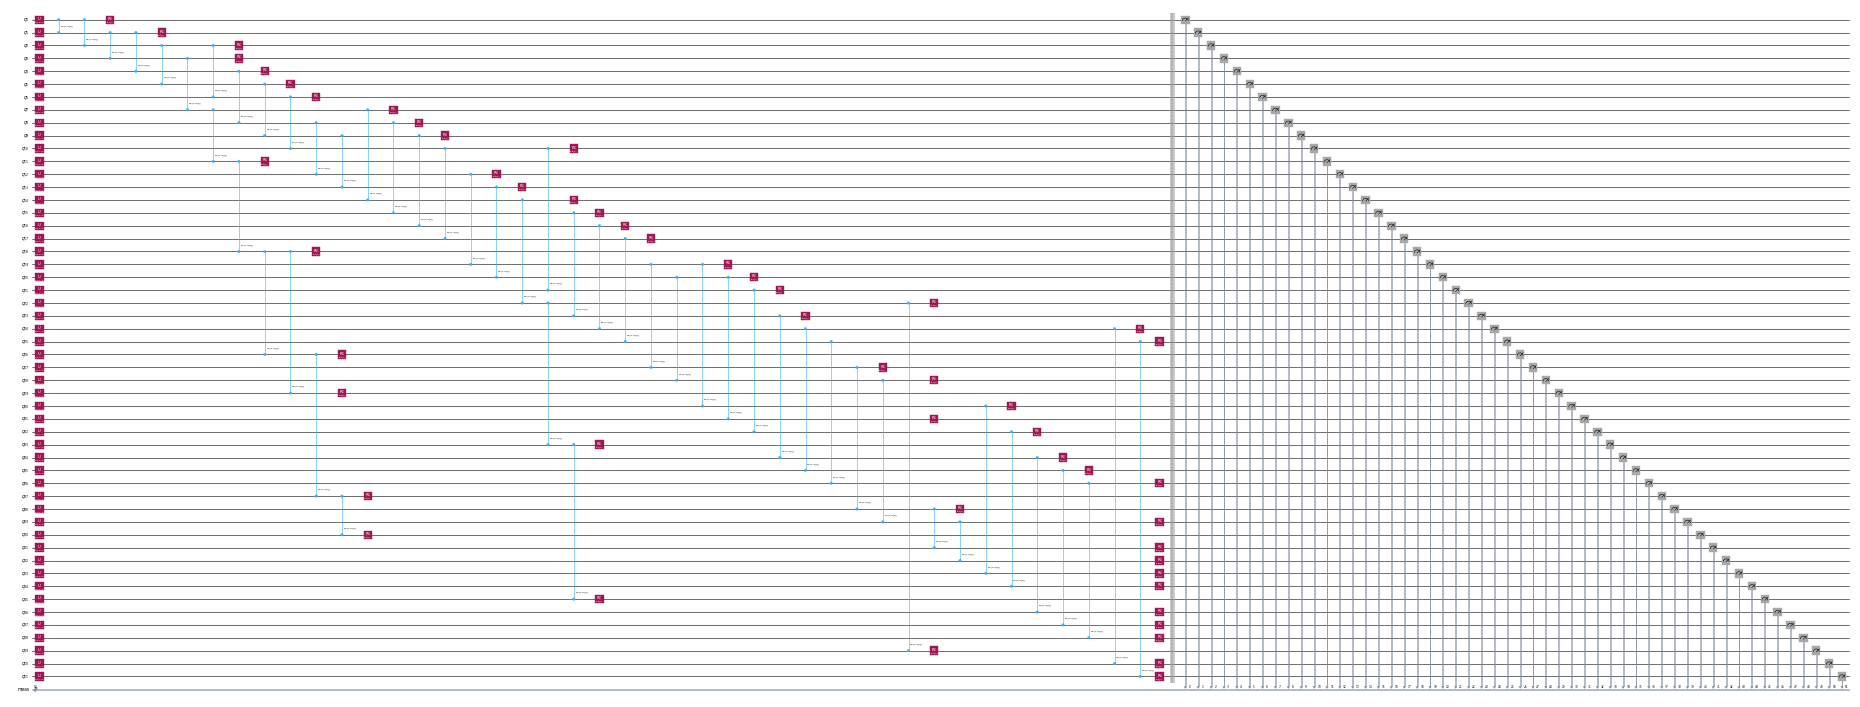

In [10]:
from qiskit.circuit.library import QAOAAnsatz

circuit_max_cut = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=1)
circuit_max_cut.measure_all()
# Decompose to make it a bit more clear what happens.
circuit_max_cut.decompose(reps=2).draw('mpl', fold=False, scale=0.2, idle_wires=False)

### Step 2. Optimize Problem for Quantum Execution

We now have the basic circuit, but we need to transpile it for a specific backend and, if possible, we also want to optimize it (reducing the depth and number of gates used). 

<a id="step5"></a>
<div class="alert alert-block alert-success">

**Task 5: Optimize your circuit** Add the missing code below. Choose a suitable backend, and set parameters to make sure you get an optimized result.

> Hint: if you have problems with the layout look at the information about the GHZ state you have above.

</div> 


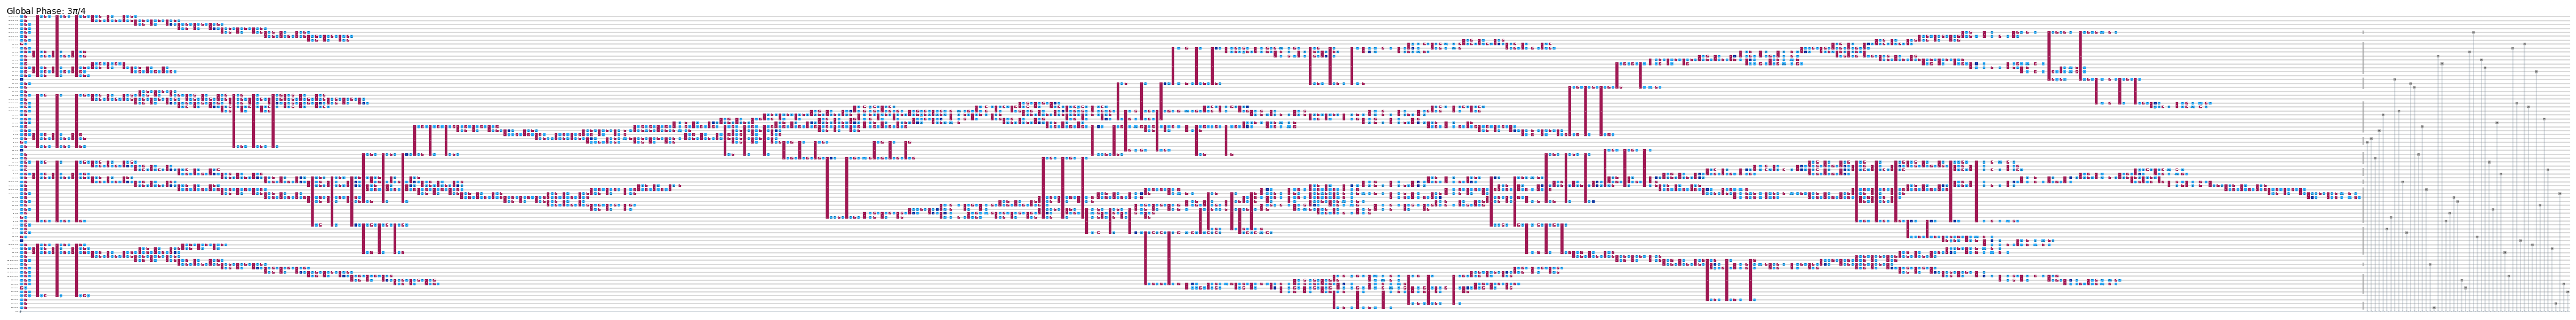

In [11]:
service = QiskitRuntimeService()
chosen_backend = service.least_busy(min_num_qubits=52)

# How the virtual qubits are mapped to the physical ones for the given GHZ circuit.
chosen_layout = premade_layout # ADD CODE HERE

pm = generate_preset_pass_manager(initial_layout=chosen_layout,
                                    optimization_level=3,  # ADD CODE HERE choose optimization level
                                    backend=chosen_backend)

candidate_circuit_max_cut = pm.run(circuit_max_cut)
candidate_circuit_max_cut.draw('mpl', fold=False, scale=0.1, idle_wires=False)

In [12]:
print(chosen_backend)


<IBMBackend('ibm_strasbourg')>


### Step 3. Execute Using Qiskit Primitives

To run QAOA, we need good values for the variational parameters $\gamma_k$ and $\beta_k$, which define the layers of the QAOA circuit.

We determine these parameters by running an optimization loop on the device (or simulator).
During optimization, the code will repeatedly submit jobs, evaluate the cost function, and update the parameters until the value converges, that is, until the improvement becomes negligibly small and the optimal $\gamma_k$ and $\beta_k$ are found.

Convergence speed depends on the optimizer and the initial starting point.
Some choices converge quickly; others may take more iterations and cost more device time.

If you have time (and enough real-device resources), you can experiment by trying different optimizers or starting parameter values to see how they affect convergence.


**Estimated Time on device: 18 Minutes:**


#### Find candidate solution by running the optimization on the device


First, run the optimization loop for finding the circuit parameters on a device. 

Choose a suitable optimization method and starting parameters below.  

Use this reference for choosing the minimization method: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html


<div class="alert alert-block alert-danger">

**Session is a blocking operation!:** This means that while the session is running, your computer must stay active, and you cannot execute any other cells in this Jupyter notebook until the session finishes.

</div>

In [13]:
def cost_function(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)


    return cost

<a id="step5"></a>
<div class="alert alert-block alert-success">

**Task 6: Choose optimization parameters** Add the missing code below. Choose a suitable method and parameters.

> How fast does it converge? Check with the plot below.   

</div> 

In [ ]:
# Add your code below

classical_optimizer = 'COBYLA' # Choose a classical optimization method
initial_gamma = 0.1 # Try some starting parameters
initial_beta = 0.1 # Try some starting parameters

init_params = [initial_gamma, initial_beta]

objective_func_vals = [] # Global variable
with Session(backend=chosen_backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"


    result = minimize(
        cost_function,
        init_params, 
        args =(candidate_circuit_max_cut, cost_hamiltonian, estimator),
        method=classical_optimizer,
    )
    print(result)

c:\Users\CRuizQM\Github\BasQ-IBM\.venv\Lib\site-packages\qiskit_ibm_runtime\qiskit_runtime_service.py:1207: UserWarning: There is currently no more time available for this instance's plan on the account. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aeu-de%3Aa%2Fcb804b30dfcb48b890393bfd6e41e9c2%3Ae495fc76-27a7-45bf-8289-d7ac75454ff5%3A%3A for more details.
  warnings.warn(


### Step 4. Post-process and Return the Result in a Classical Format


Here we can check that the cost minimized in the optimization loop has converged to a certain value. 

The code below uses the parameters corresponding to the minimum value of the cost.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

### Creating the actual cut.

We now have the optimal parameters for the QAOA circuit, but these parameters are not the final output we want.

Our goal is to obtain the cut of the graph.

To do that, we take the optimal parameters and use them to build the final QAOA circuit, which we will then execute to sample bitstrings that represent the cut.

In [ ]:
optimized_circuit_max_cut = candidate_circuit_max_cut.assign_parameters(result.x)
optimized_circuit_max_cut.draw('mpl', fold=False, idle_wires=False)

Finally, execute the circuit with the optimal parameters to sample from the corresponding distribution.


Sampling here means that we use the circuit several times each one gives us a solution.
However, because of noise on the device, we can have some variance in the output. 

Therefore we sample several times in order to find a good/the best solution. 

Going through all the samples, i.e. possible solutions (which are near to the actual one) is a lot faster than trying just brute force all possibilities.

We use 10^4 samples here, all possibilities would be 2^50 which is roughly 10^15 which is a way bigger search space.

In [ ]:
# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`

# set shots for everything

sampler = Sampler(mode=chosen_backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"


pub= (optimized_circuit_max_cut, )
job = sampler.run([pub], shots=int(1e4))

counts_int = job.result()[0].data.meas.get_int_counts()
shots = sum(counts_int.values())
final_distribution = {key: val/shots for key, val in counts_int.items()}

print(len(counts_int))

#Change using only keys from counts.items 

Given that the likelihood of each solution is low, extract the solution that corresponds to the lowest cost.


<a id="step5"></a>
<div class="alert alert-block alert-success">

**Task 7: Find the best solution** We have now many samples, which all represent potential solutions. Find the best solution.

> When you found your solution, visualize it with the function below (after visualization).
>
> Hint: If you dont know what to do, you can find one potential way here: https://learning.quantum.ibm.com/tutorial/quantum-approximate-optimization-algorithm but try it yourself first:
>
> Think about what makes the best solution? And how can we extract it with the samples.
> 

</div> 


In [ ]:
_PARITY = np.array([-1 if bin(i).count("1") % 2 else 1 for i in range(256)], dtype=np.complex128)


## Auxiliary function helping to calculate the cost for a given state (sample output)
## You dont need to understand this in detail.
def calculate_cost(state: int, observable: SparsePauliOp) -> complex:
    """Utility for the evaluation of the expectation value of a measured state."""
    packed_uint8 = np.packbits(observable.paulis.z, axis=1, bitorder="little")
    state_bytes = np.frombuffer(state.to_bytes(packed_uint8.shape[1], "little"), dtype=np.uint8)
    reduced = np.bitwise_xor.reduce(packed_uint8 & state_bytes, axis=1)
    return np.sum(observable.coeffs * _PARITY[reduced]).real

def to_bitstring(value: int, length: int) -> list[int]:
    """Convert an integer to a bitstring of fixed length."""
    return [int(bit) for bit in bin(value)[2:].zfill(length)]

# Add the missing code to finish this function.
def best_solution(samples, hamiltonian):
    """Find solution with lowest cost"""
    min_sol = None
    min_cost = 1000
    for sample in samples.keys():
        #Add code here
        sol = int(sample)
        cost=calculate_cost(sample, hamiltonian)
        #Add code here
        if cost < min_cost:
            min_cost = cost
            min_sol = sol

    return min_sol

best_solution = best_solution(final_distribution, cost_hamiltonian)
best_solution_string = to_bitstring(int(best_solution), len(prepared_graph))
best_solution_string.reverse()

print("Result bitstring:", best_solution_string)

### Visualization

We want to visualize the cut. Nodes of the same color belong to the same group.


In [ ]:
# auxiliary function to plot graphs
def plot_result(G, x):
    #colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    colors = ["r" if x[i] == 0 else "c" for i in range(n)]

    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)


plot_result(prepared_graph, best_solution_string)

And then calculate the the value of the cut. What should the ideal value be? Think about the start of the exercise. 


In [ ]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(x[u] * (1 - x[v]) + x[v] * (1 - x[u]) for u, v in list(graph.edge_list()))


cut_value= evaluate_sample(best_solution_string, prepared_graph)
print('The value of the cut is:', cut_value)